# 🚢 Titanic Survival Prediction Using Machine Learning

## Objective
Predict passenger survival on the Titanic using demographic and travel data.
Multiple machine learning classification models are trained, cross-validated,
and compared using F1-score to select the best model.

## Dataset
- Kaggle Titanic Dataset
- train.csv (training & validation)
- test.csv (final prediction)

## Evaluation Metrics
Accuracy, Precision, Recall, F1-Score


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from xgboost import XGBClassifier

sns.set_style("whitegrid")

In [41]:
train_df = pd.read_csv("/content/train.csv")
test_df = pd.read_csv("/content/test.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [42]:
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [43]:
train_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


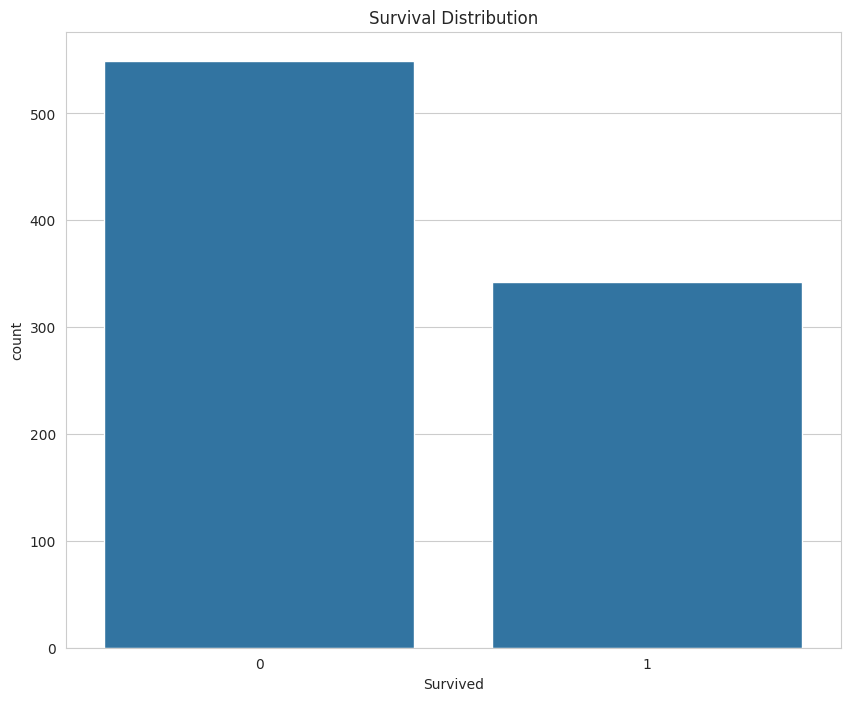

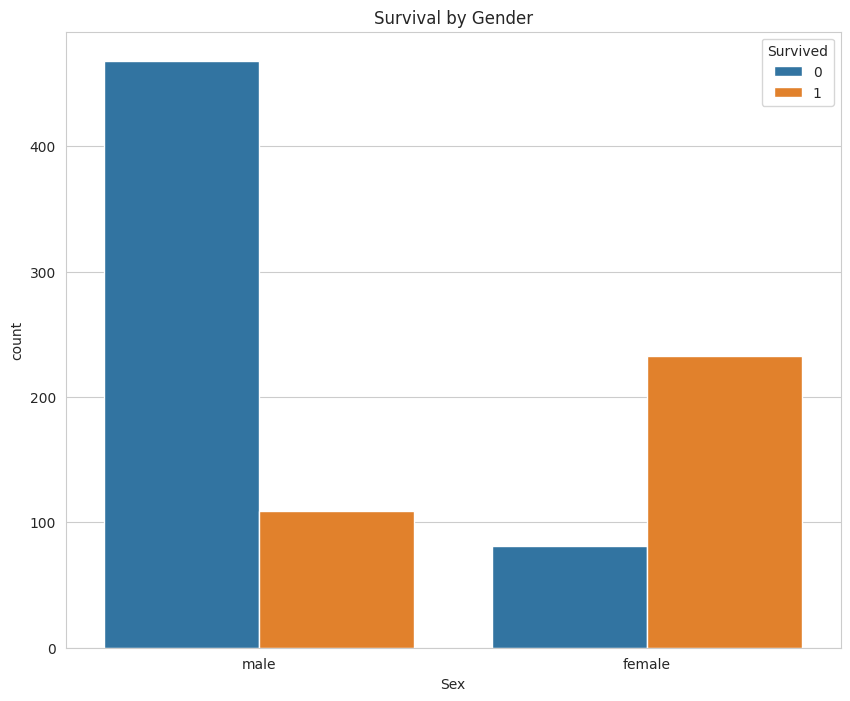

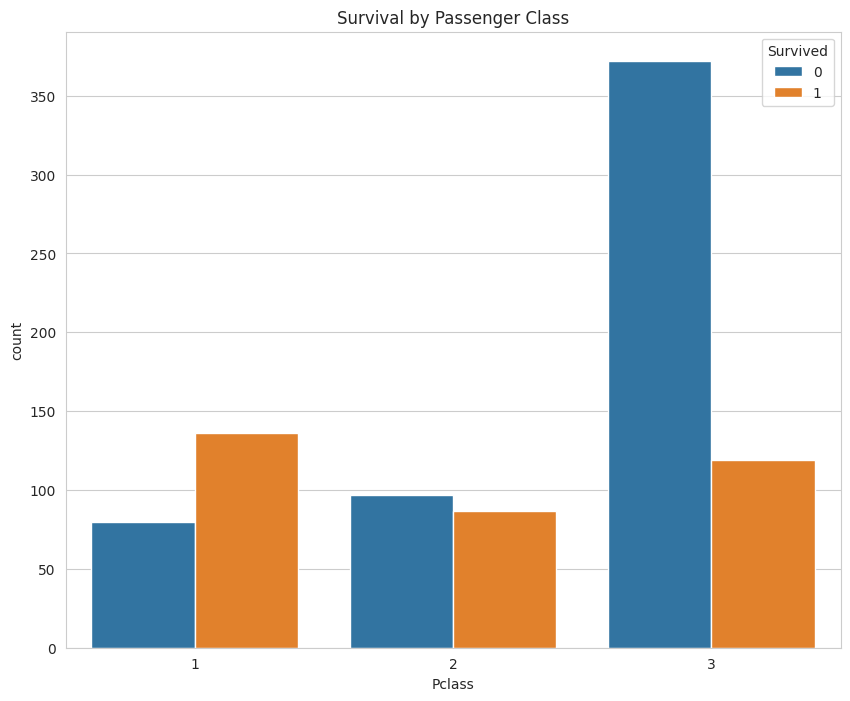

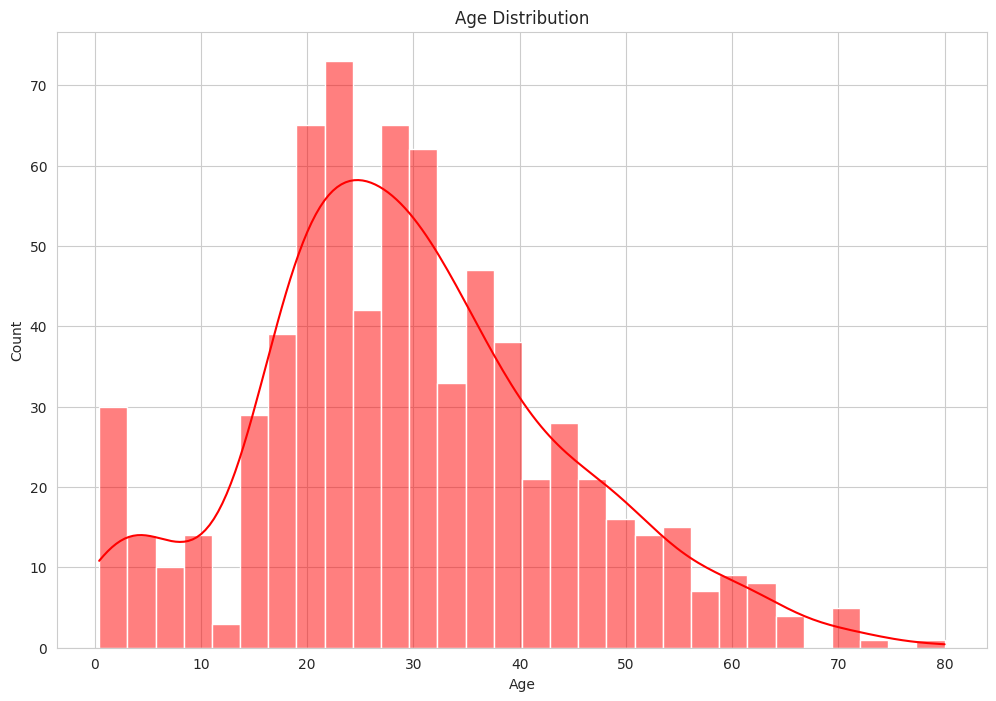

In [44]:
plt.figure(figsize=(10,8))
sns.countplot(x="Survived", data=train_df)
plt.title("Survival Distribution")
plt.show()

plt.figure(figsize=(10,8))
sns.countplot(x="Sex", hue="Survived", data=train_df)
plt.title("Survival by Gender")
plt.show()

plt.figure(figsize=(10,8))
sns.countplot(x="Pclass", hue="Survived", data=train_df)
plt.title("Survival by Passenger Class")
plt.show()

plt.figure(figsize=(12,8))
sns.histplot(train_df["Age"], bins=30, kde=True,color='red')
plt.title("Age Distribution")
plt.show()


### Data Preprocessing
- Handle missing values
- Encode categorical variables
- Scale numerical features


In [45]:
full_df = pd.concat([train_df.drop("Survived", axis=1), test_df])

full_df["Age"] = full_df["Age"].fillna(full_df["Age"].median())
full_df["Fare"] = full_df["Fare"].fillna(full_df["Fare"].median())
full_df["Embarked"] = full_df["Embarked"].fillna(full_df["Embarked"].mode()[0])

full_df.drop(["Name", "Ticket", "Cabin"], axis=1, inplace=True)

le = LabelEncoder()
full_df["Sex"] = le.fit_transform(full_df["Sex"])
full_df["Embarked"] = le.fit_transform(full_df["Embarked"])

In [46]:
X = full_df.iloc[:len(train_df)].drop("PassengerId", axis=1)
X_test_final = full_df.iloc[len(train_df):].drop("PassengerId", axis=1)

y = train_df["Survived"]
test_passenger_ids = test_df["PassengerId"]

In [47]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test_final = scaler.transform(X_test_final)

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(eval_metric="logloss")
}

In [49]:
results = []

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring="f1").mean()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results.append([
        name,
        accuracy_score(y_val, y_pred),
        precision_score(y_val, y_pred),
        recall_score(y_val, y_pred),
        f1_score(y_val, y_pred),
        cv_f1
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1_Score", "CV_F1"]
)

results_df.sort_values("F1_Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1_Score,CV_F1
1,Random Forest,0.832402,0.809524,0.739130,0.772727,0.733438
4,XGBoost,0.810056,0.753623,0.753623,0.753623,0.728471
3,KNN,0.810056,0.786885,0.695652,0.738462,0.742531
2,SVM,0.815642,0.833333,0.652174,0.731707,0.745511
0,Logistic Regression,0.798883,0.779661,0.666667,0.718750,0.725031


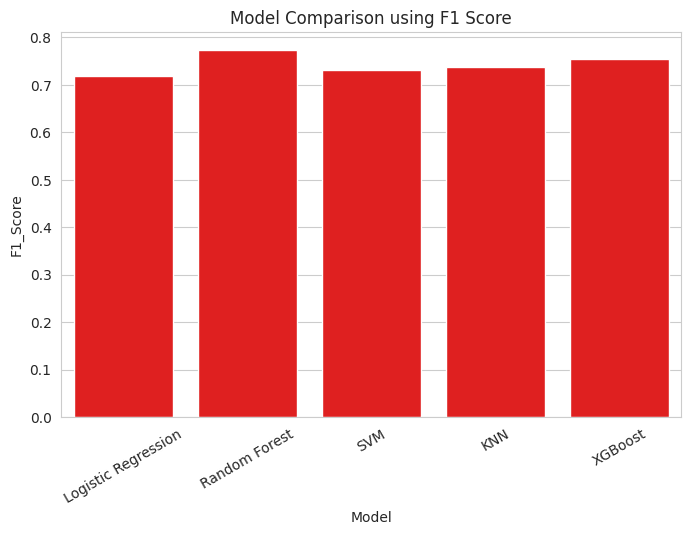

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1_Score", data=results_df,color='red')
plt.xticks(rotation=30)
plt.title("Model Comparison using F1 Score")
plt.show()

Best Model: Random Forest


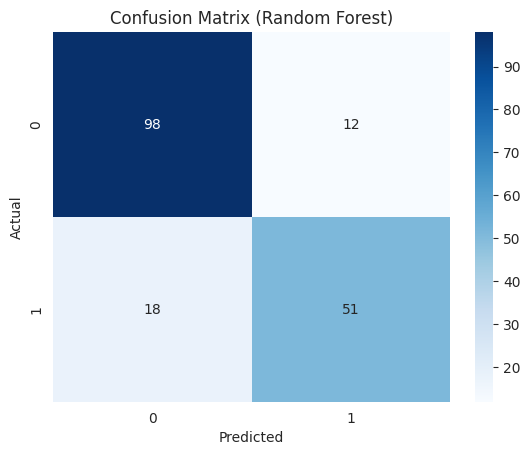

In [51]:
best_model_name = results_df.sort_values("F1_Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_val)

print("Best Model:", best_model_name)

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
best_model.fit(X_train, y_train)

test_predictions = best_model.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test_predictions
})

submission.to_csv("submission.csv", index=False)
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,0


## Conclusion
- Multiple classification models were evaluated for Titanic survival prediction.
- F1-score was chosen due to class imbalance.
- Ensemble models showed superior performance.
- Final predictions were generated for unseen test data.
